# 09 · Rating curves

Fit a stage–discharge relationship to paired field measurements and compare
one-, two-, and three-segment synthetic examples. Restart Kernel and Run All
constructs each time series and estimates each curve from raw observations.
API reference: `RatingCurveExampleFixtures.cs` creates the model from paired
time series; `RatingCurveExampleRecoveryTests.cs` runs the Bayesian analysis.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
import numpy as np
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
runtime = load_bestfit()
print(runtime)
from System import Array, Double, DateTime
from Numerics.Data import TimeSeries, TimeInterval, SeriesOrdinate
from Numerics.Distributions import Uniform
from RMC.BestFit.Models import RatingCurve
from RMC.BestFit.Analyses import RatingCurveAnalysis
from RMC.BestFit.Estimation import BayesianAnalysis

# Independent SciPy discharge-space log-likelihoods from the pinned Verification
# fixture, evaluated at known generating parameters (not saved BestFit estimates).
synthetic_oracle = {
    1: ([1., .24389656534469958, 2.6666666666666665, .05], -1577.7594156516989),
    2: ([1., .24389656534469958, 2.6666666666666665, 10., 2.9462998885606555, 1.67, .05],
        -1850.3134085800252),
    3: ([1., .24389656534469958, 2.6666666666666665, 10., 2.9462998885606555, 1.67,
         15., 3.6095332363473847, 1.67, .05], -1888.5687896304166),
}

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Field and synthetic paired observations

The USGS 07024175 series holds 96 irregular-date stage/discharge pairs. The
synthetic project holds 300 daily stages and a separate discharge series per
segment design. Dates, units and measured values come from the raw fixtures;
saved fitted curves and posterior draws are never inputs to this notebook.

In [3]:
field_raw = load_raw("usgs-07024175-mississippi-rating-curve")
synthetic_raw = load_raw("synthetic-rating-curve-examples")
case_specs = [
    ("USGS 07024175 Rating Curve", field_raw, "USGS 07024175 Measured Stage",
     "USGS 07024175 Measured Discharge", 1, "PosteriorMode", 8, 40),
    ("1 Segment Rating Curve", synthetic_raw, "Stage Data",
     "1 Segment - Flow Data", 1, "PosteriorMean", 8, 40),
    ("2 Segment Rating Curve", synthetic_raw, "Stage Data",
     "2 Segment - Flow Data", 2, "PosteriorMean", 14, 70),
    ("3 Segment Rating Curve", synthetic_raw, "Stage Data",
     "3 Segment - Flow Data", 3, "PosteriorMean", 20, 100),
]
display(pd.DataFrame([{"Case": name, "Stage records": len(raw["series"][stage]["records"]),
                       "Discharge records": len(raw["series"][flow]["records"]),
                       "Time interval": raw["series"][stage]["attributes"]["TimeInterval"]}
                      for name, raw, stage, flow, *_ in case_specs]))
print(field_raw["source"])
print(synthetic_raw["source"])

,Case,Stage records,Discharge records,Time interval
0,USGS 07024175 Rating Curve,96,96,Irregular
1,1 Segment Rating Curve,300,300,OneDay
2,2 Segment Rating Curve,300,300,OneDay
3,3 Segment Rating Curve,300,300,OneDay


{'bytes': 8519680, 'relative_path': 'examples/6-rating-curve-analysis/usgs-07024175-mississippi-rating-curve.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': '997fe961e233f540cf64171dfd5b2475b23b9f4ac8cc51459dd545b242a24ece'}
{'bytes': 22872064, 'relative_path': 'examples/6-rating-curve-analysis/synthetic-rating-curve-examples.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': 'e18dd2f001c4fa16add8e66162ed80ac5dd2057b6d915f106ec5c799cab1bb17'}


## Construct time series and rating models

For the irregular field data, add each timestamp explicitly. For the synthetic
daily data, the public constructor builds the regular dates from the first date
and values. Both series in each case must align on date; do not pair by sorted
values. BestFit uses Gaussian residuals in log10 discharge and a Jeffreys
prior on the residual scale. The default flat coefficient priors are preserved.

In [4]:
analyses, models, timings, pair_counts = {}, {}, {}, {}
for name, raw, stage_name, flow_name, segments, estimator, chains, thinning in case_specs:
    stage_rows = raw["series"][stage_name]["records"]
    flow_rows = raw["series"][flow_name]["records"]
    assert len(stage_rows) == len(flow_rows)
    assert all(s["Index"] == q["Index"] for s, q in zip(stage_rows, flow_rows))
    assert all(float(q["Value"]) > 0 for q in flow_rows)
    interval = raw["series"][stage_name]["attributes"]["TimeInterval"]
    assert interval == raw["series"][flow_name]["attributes"]["TimeInterval"]
    if interval == "Irregular":
        stage = TimeSeries(TimeInterval.Irregular)
        discharge = TimeSeries(TimeInterval.Irregular)
        for s, q in zip(stage_rows, flow_rows):
            stage.Add(SeriesOrdinate[DateTime, Double](DateTime.Parse(s["Index"]), float(s["Value"])))
            discharge.Add(SeriesOrdinate[DateTime, Double](DateTime.Parse(q["Index"]), float(q["Value"])))
    else:
        assert interval == "OneDay"
        start = DateTime.Parse(stage_rows[0]["Index"])
        stage = TimeSeries(TimeInterval.OneDay, start,
                           Array[Double]([float(row["Value"]) for row in stage_rows]))
        discharge = TimeSeries(TimeInterval.OneDay, start,
                               Array[Double]([float(row["Value"]) for row in flow_rows]))
    model = RatingCurve(stage, discharge, segments)
    model.UseDefaultFlatPriors = True
    model.UseJeffreysRuleForScale = True
    assert model.NumberOfSegments == segments
    if raw is synthetic_raw and segments in (1, 3):
        # The source examples admit exponent zero; the current constructor
        # starts at 0.1 for these coordinates. Preserve authored support.
        for parameter_index in ([2] if segments == 1 else [2, 5, 8]):
            model.Parameters[parameter_index].LowerBound = 0.0
            model.Parameters[parameter_index].UpperBound = 5.0
            model.Parameters[parameter_index].PriorDistribution = Uniform(0.0, 5.0)
    if raw is synthetic_raw:
        generating_parameters, oracle_log_likelihood = synthetic_oracle[segments]
        likelihood = float(model.DataLogLikelihood(Array[Double](generating_parameters)))
        assert abs(likelihood - oracle_log_likelihood) < 1e-4
    analysis = RatingCurveAnalysis(model)
    analysis.Name = name
    analysis.UseDefaultStageBins = True
    analysis.StageBins = 100
    # These are the saved app's display/processing ranges, not estimated parameters.
    if raw is field_raw:
        analysis.MinStage, analysis.MaxStage = -10.32, 45.96
    else:
        analysis.MinStage, analysis.MaxStage = -.7326817927, 21.7691008757
    bayes = analysis.BayesianAnalysis
    bayes.UseSimulationDefaults = True
    bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
    bayes.NumberOfChains = chains
    bayes.ThinningInterval = thinning
    bayes.WarmupIterations = 1750
    bayes.Iterations = 3500
    bayes.PRNGSeed = 12345
    bayes.UseAdvancedSimulationDefaults = True
    bayes.InitialIterations = {1: 400, 2: 700, 3: 1000}[segments]
    bayes.Jump = {1: .8414570696119914, 2: .63608175575157, 3: .53218417864494993}[segments]
    bayes.CredibleIntervalWidth = .9
    bayes.OutputLength = 10000
    bayes.PointEstimator = getattr(BayesianAnalysis.PointEstimateType, estimator)
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name], models[name] = analysis, model
    pair_counts[name] = model.GetDataAlignmentCounts().Item3
    record_run(name, analysis, timings[name], raw=raw, model=model)

USGS 07024175 Rating Curve: completed in 3.25 s. Execution alone does not establish convergence or scientific acceptance.


1 Segment Rating Curve: completed in 6.52 s. Execution alone does not establish convergence or scientific acceptance.


2 Segment Rating Curve: completed in 21.89 s. Execution alone does not establish convergence or scientific acceptance.


3 Segment Rating Curve: completed in 38.26 s. Execution alone does not establish convergence or scientific acceptance.


## Read fitted results and inspect residuals

A smooth curve can conceal systematic residual structure. The residual views
show deviations in log10 discharge, the same scale used by the likelihood.
These four likelihoods describe distinct datasets and should not be ranked
against one another to select the number of controls for the field site.

,Case,Segments,Paired measurements,Parameters,Estimator,Scale posterior mean,AIC,BIC,RMSE
0,USGS 07024175 Rating Curve,1,96,4,PosteriorMode,0.023194,2233.464524,2243.721917,30328.581766
1,1 Segment Rating Curve,1,300,4,PosteriorMean,0.051060,3156.235968,3171.051098,224.364643
2,2 Segment Rating Curve,2,300,7,PosteriorMean,0.050652,3700.116115,3726.042592,2036.622768
3,3 Segment Rating Curve,3,300,10,PosteriorMean,0.050661,3779.386122,3816.423947,4042.050521


,Parameter,Posterior mean
0,Zero-Flow Stage (h₁),-50.941541
1,Coefficient (α₁),-0.243985
2,Exponent (β₁),3.253458
3,Scale (σ),0.023194


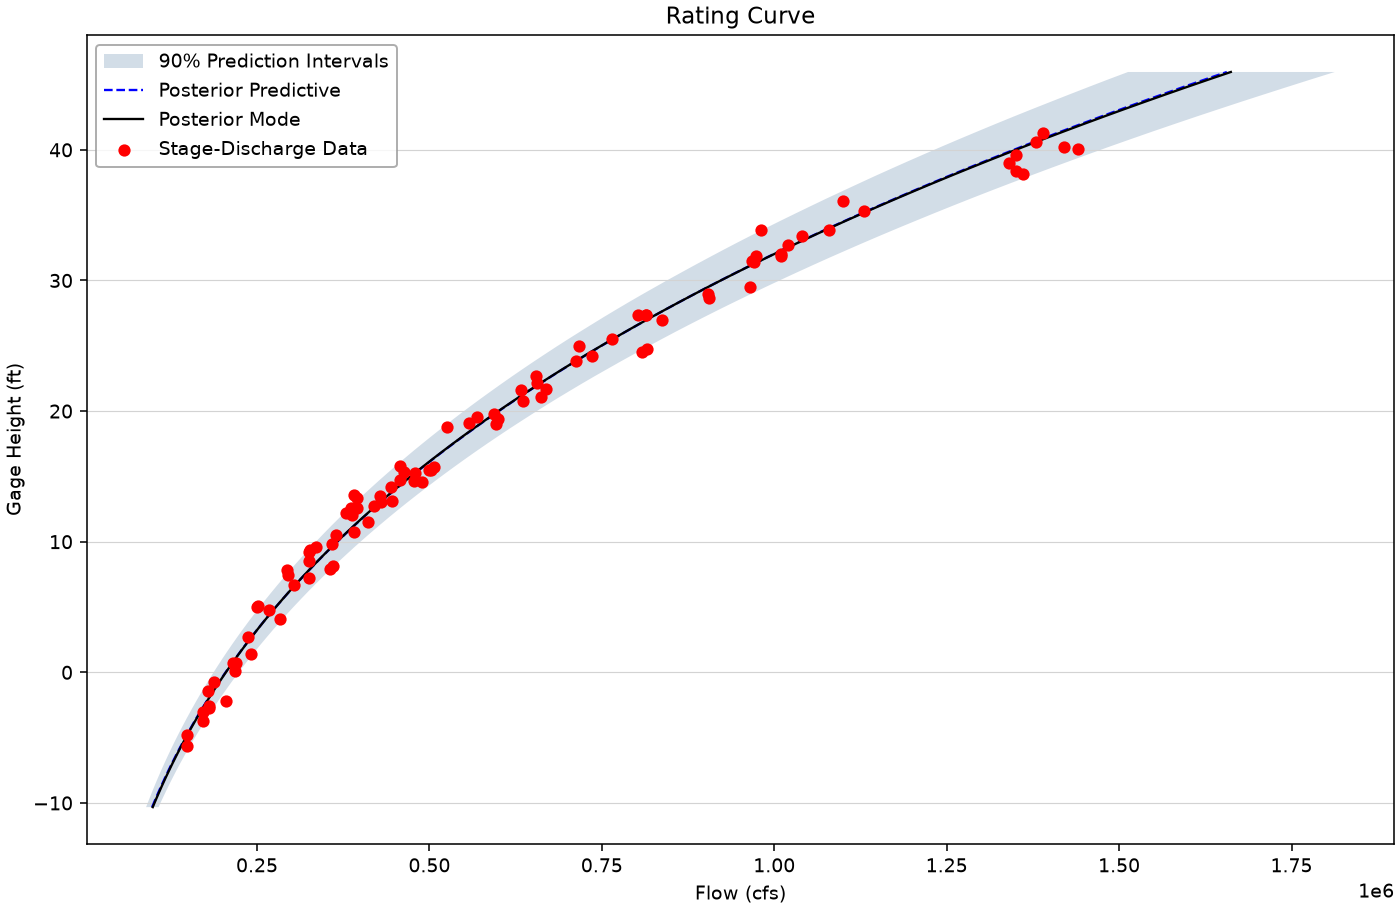

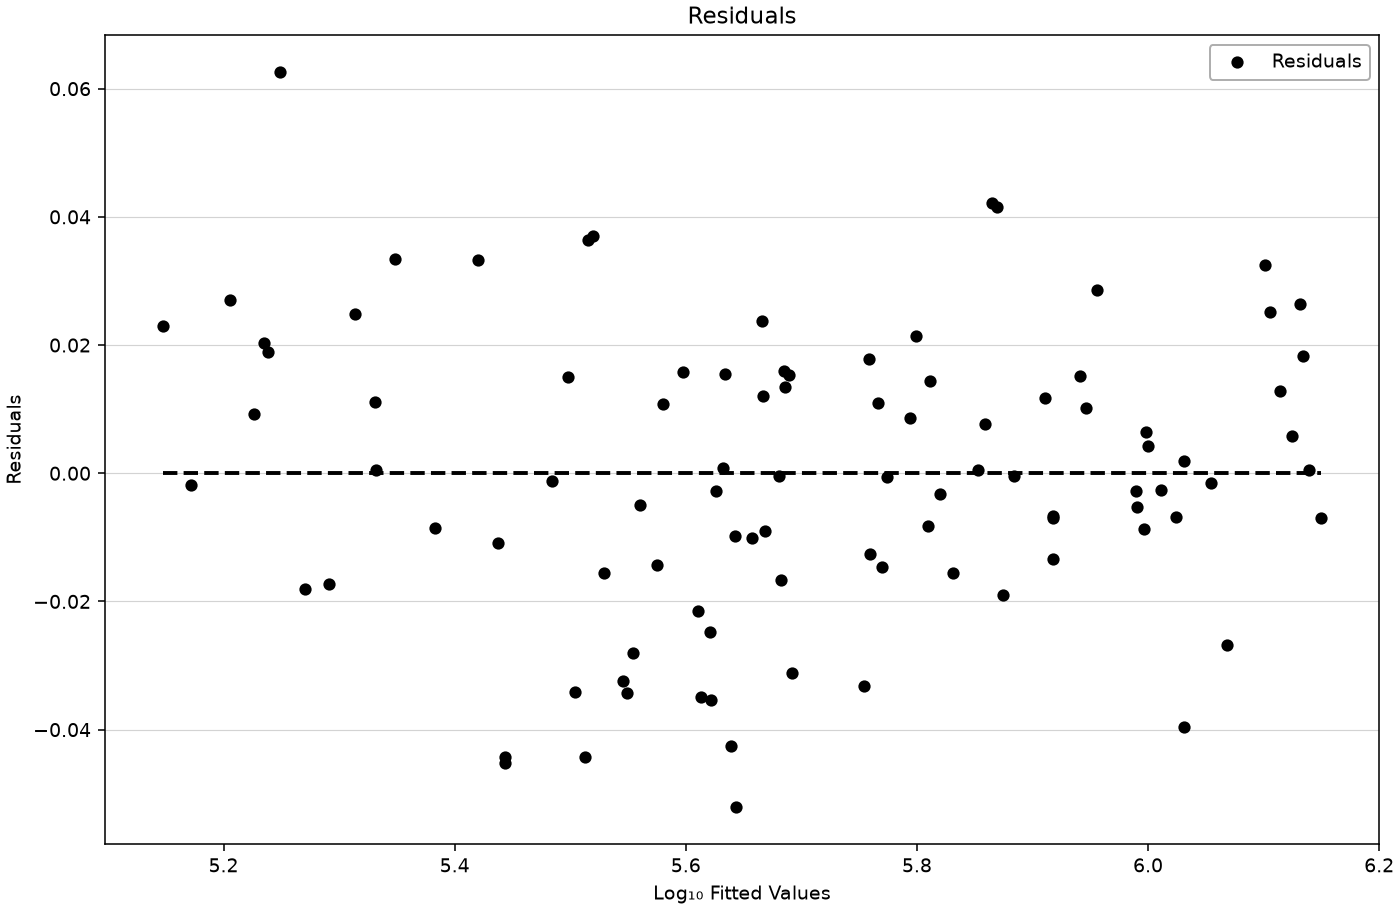

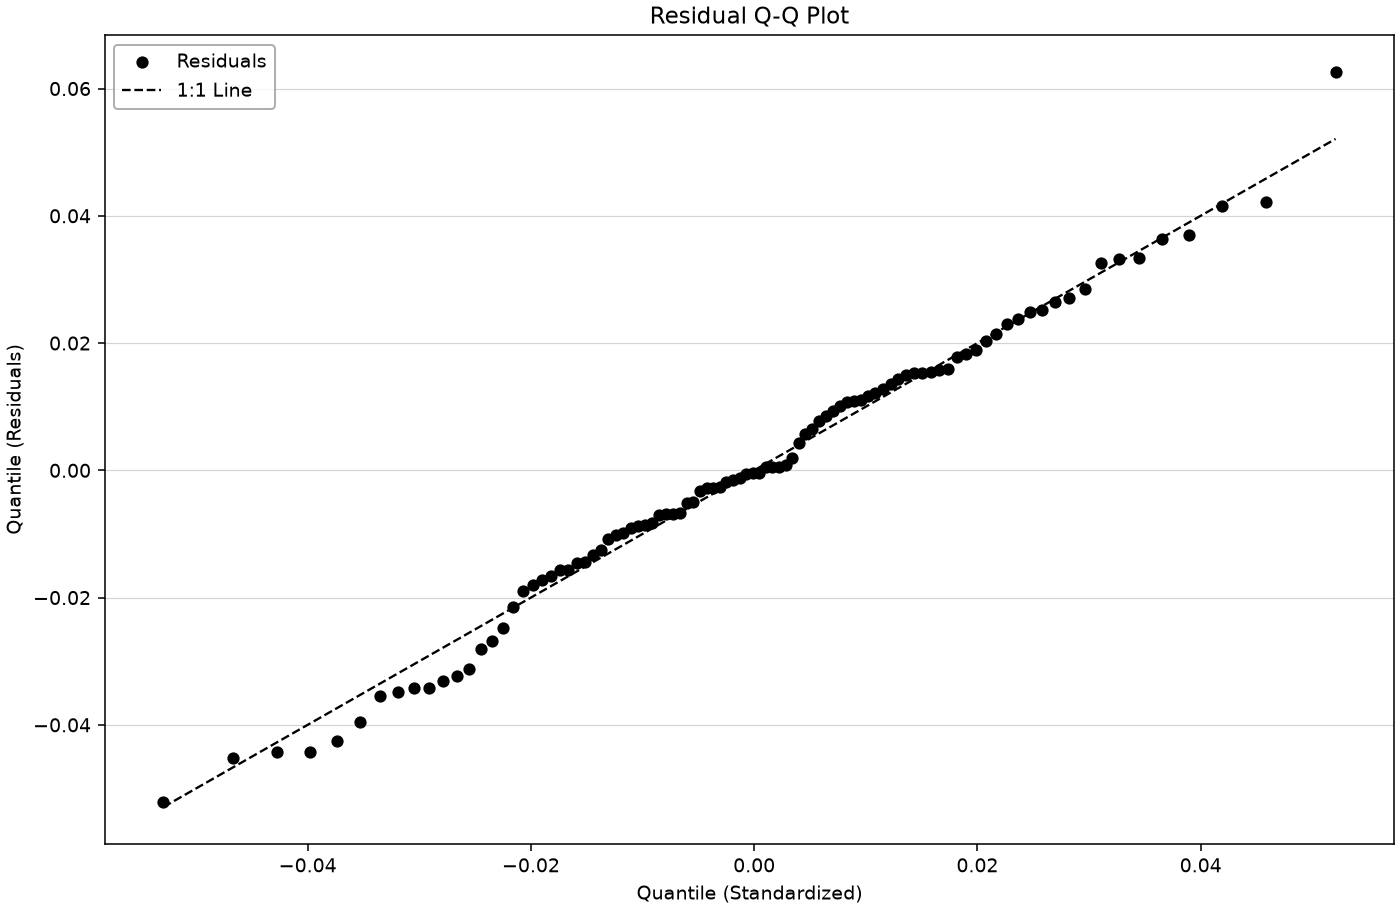

In [5]:
rows = []
for name, raw, stage_name, flow_name, segments, estimator, chains, thinning in case_specs:
    analysis, model = analyses[name], models[name]
    result = analysis.BayesianAnalysis.Results
    assert analysis.IsEstimated and result is not None
    rows.append({"Case": name, "Segments": segments, "Paired measurements": pair_counts[name],
                 "Parameters": model.NumberOfParameters, "Estimator": estimator,
                 "Scale posterior mean": float(result.PosteriorMean.Values[model.NumberOfParameters-1]),
                 "AIC": float(analysis.AnalysisResults.AIC),
                 "BIC": float(analysis.AnalysisResults.BIC),
                 "RMSE": float(analysis.AnalysisResults.RMSE)})
display(pd.DataFrame(rows))
field_name = "USGS 07024175 Rating Curve"
field_result = analyses[field_name].BayesianAnalysis.Results
display(pd.DataFrame({"Parameter": [str(p.DisplayName) for p in models[field_name].Parameters],
                      "Posterior mean": [float(v) for v in field_result.PosteriorMean.Values]}))
field_figures = plots(plot_context(analyses[field_name], models[field_name],
                                  name=field_name, raw=field_raw,
                                  metadata=field_raw["series"]["USGS 07024175 Measured Stage"]["metadata"],
                                  discharge_row=field_raw["series"]["USGS 07024175 Measured Discharge"]["metadata"]))
show(field_figures["curve"])
show(field_figures["residuals"])
show(field_figures["residual_qq"])

## Controlled segment examples

These are separately generated discharges on the same 300 daily stages.
Their curves demonstrate where added hydraulic controls become active; they
are not evidence that the USGS site requires additional segments.

,Parameter,Posterior mean
0,Zero-Flow Stage (h₁),0.986588
1,Coefficient (α₁),0.220643
2,Exponent (β₁),2.692512
3,Scale (σ),0.051060


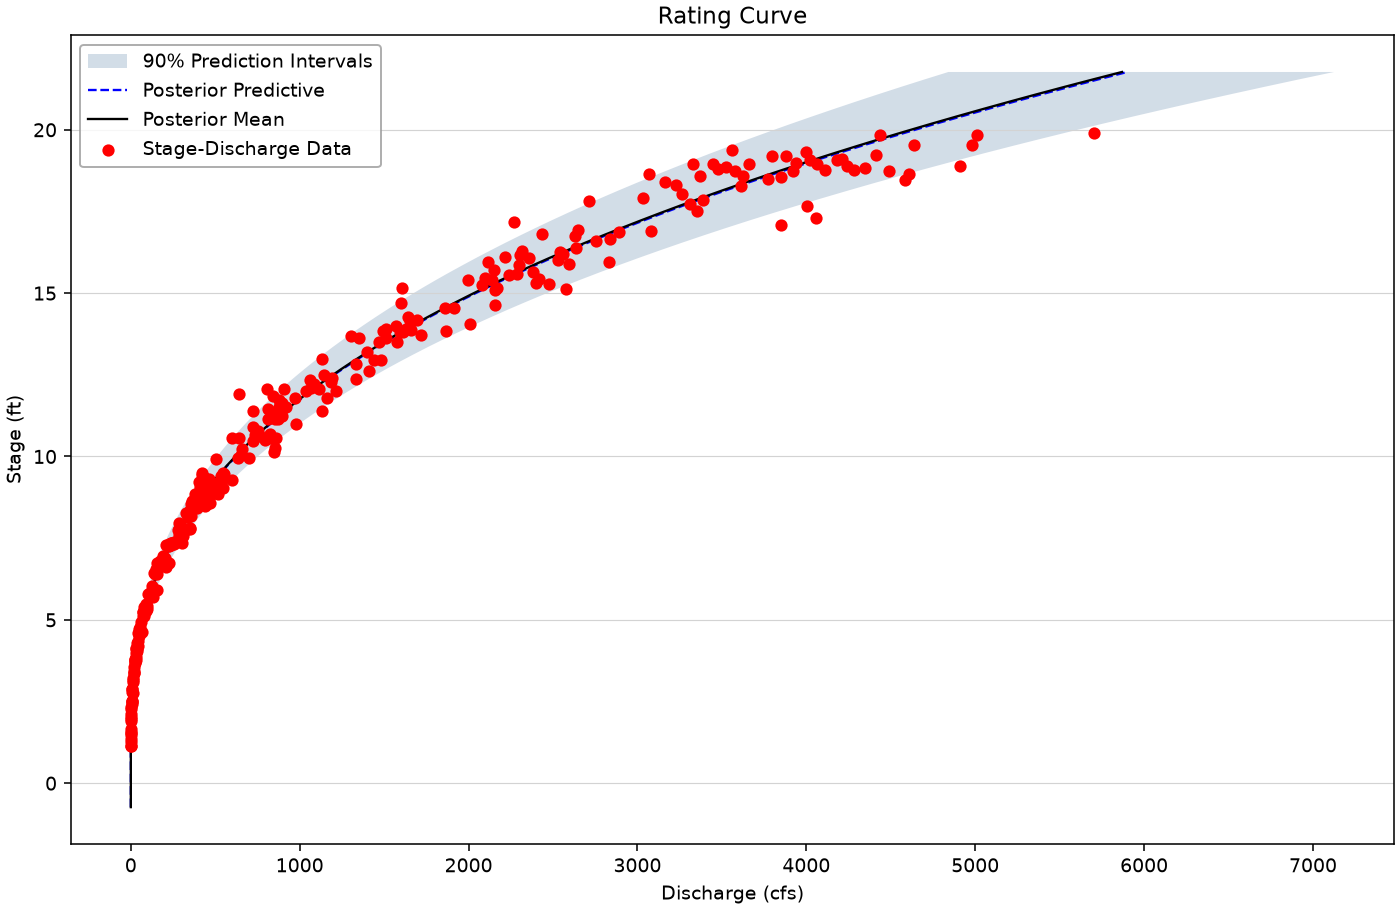

,Parameter,Posterior mean
0,Zero-Flow Stage (h₁),0.984439
1,Coefficient (α₁),0.215392
2,Exponent (β₁),2.700970
3,Activation Stage (h₂),9.847338
4,Coefficient (α₂),2.838395
5,Exponent (β₂),1.787890
6,Scale (σ),0.050652


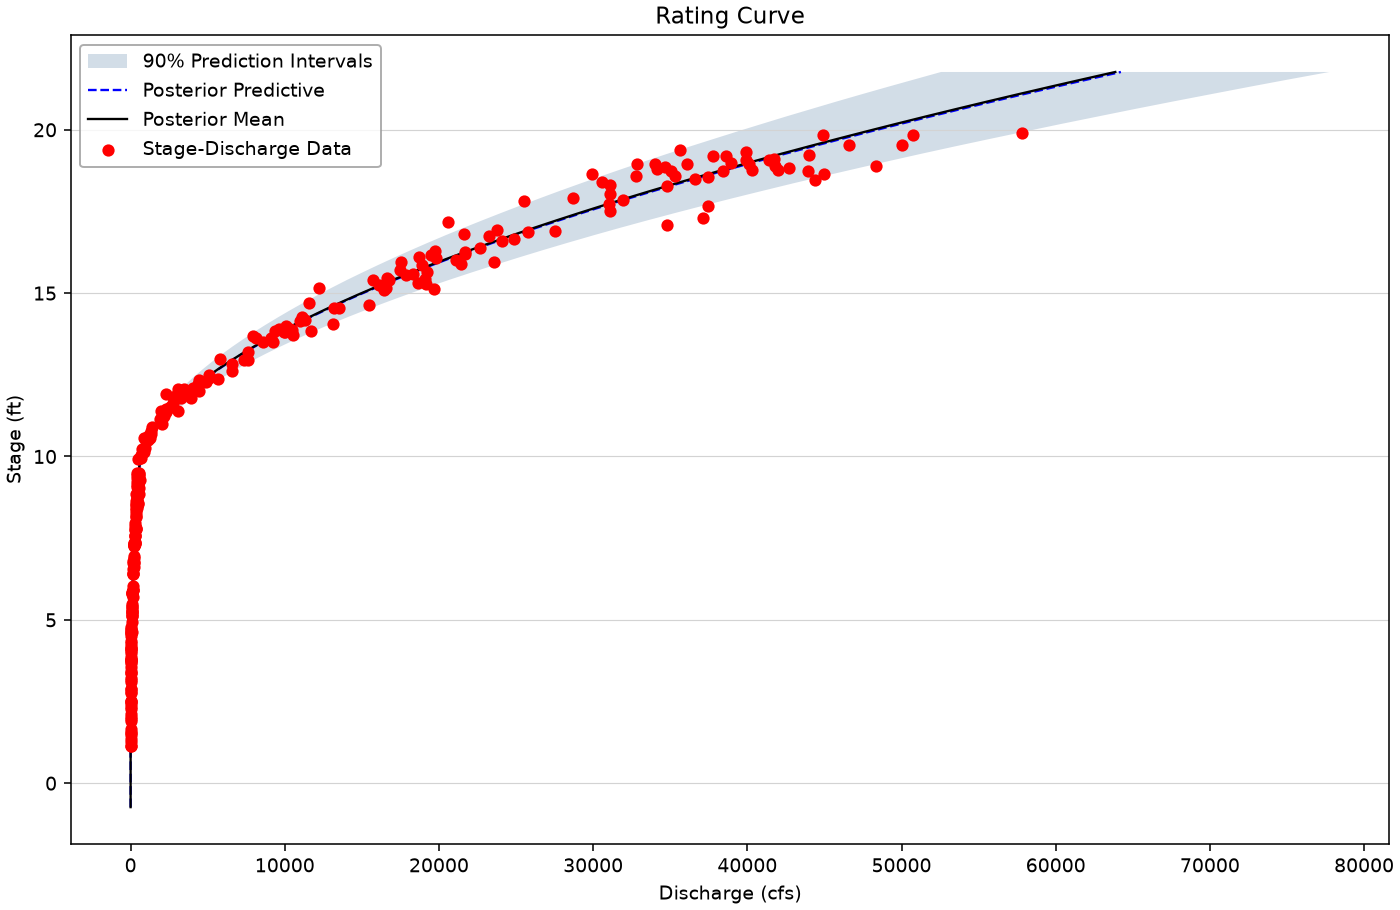

,Parameter,Posterior mean
0,Zero-Flow Stage (h₁),0.984938
1,Coefficient (α₁),0.216622
2,Exponent (β₁),2.698799
3,Activation Stage (h₂),9.705012
4,Coefficient (α₂),2.717273
5,Exponent (β₂),1.953326
6,Activation Stage (h₃),14.648034
7,Coefficient (α₃),3.155968
8,Exponent (β₃),2.171553
9,Scale (σ),0.050661


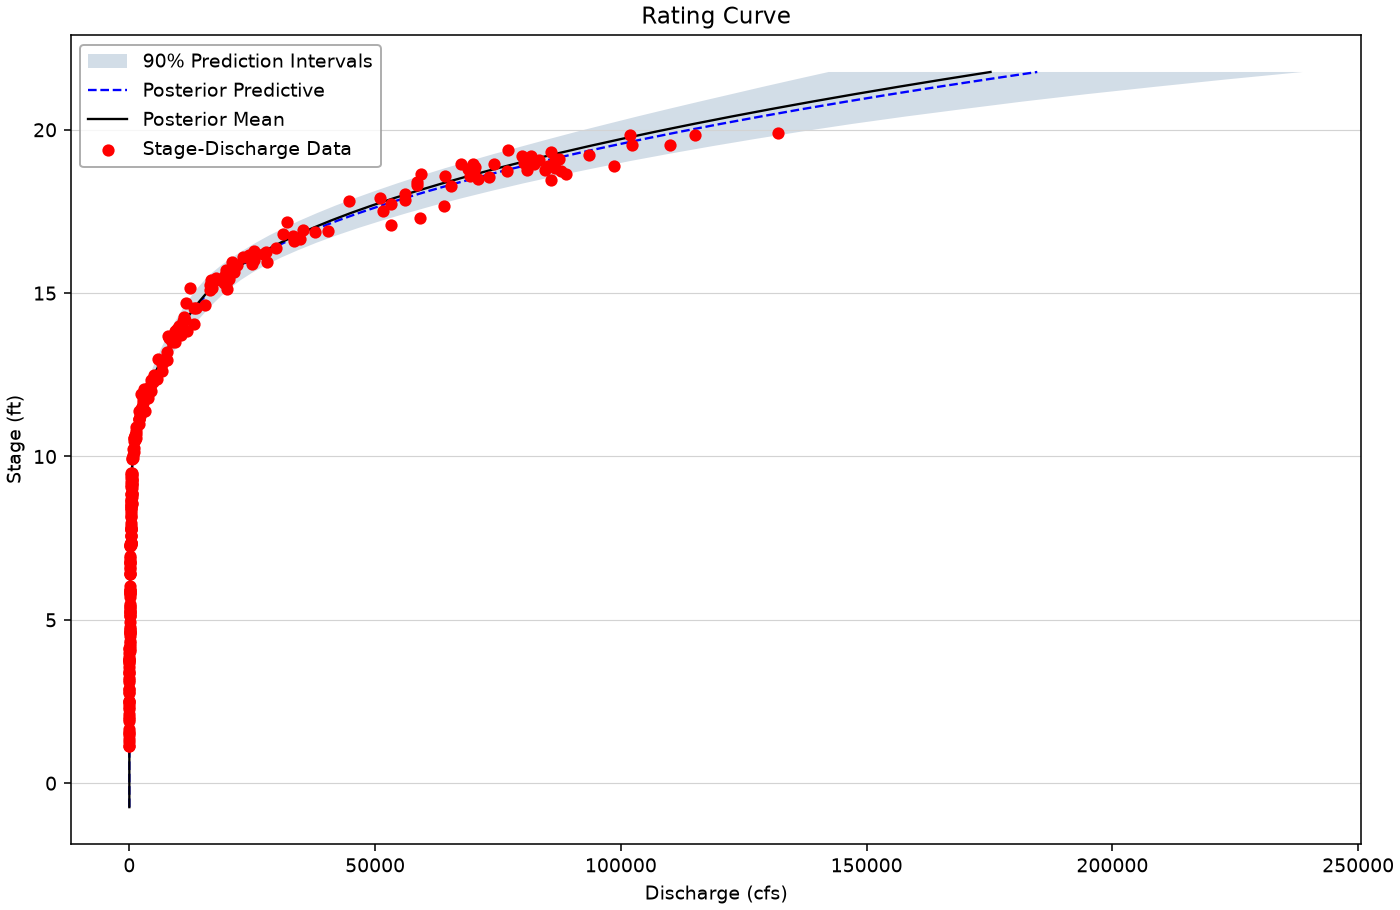

In [6]:
for name in ("1 Segment Rating Curve", "2 Segment Rating Curve", "3 Segment Rating Curve"):
    result = analyses[name].BayesianAnalysis.Results
    display(pd.DataFrame({"Parameter": [str(p.DisplayName) for p in models[name].Parameters],
                          "Posterior mean": [float(v) for v in result.PosteriorMean.Values]}))
    show(plots(plot_context(analyses[name], models[name],
                            name=name, raw=synthetic_raw,
                            metadata=synthetic_raw["series"]["Stage Data"]["metadata"],
                            discharge_row=synthetic_raw["series"][name[0] + " Segment - Flow Data"]["metadata"]))["curve"])

## Inspect parameter-level MCMC diagnostics

The R-hat and effective sample size are computed by BestFit for each fresh
posterior coordinate, including the residual scale. Inspect them before using
uncertainty bands. Good chain mixing cannot establish hydraulic suitability,
correct segment count, or independence of the field measurements.

In [7]:
diagnostic_rows = []
for name, *_ in case_specs:
    result = analyses[name].BayesianAnalysis.Results
    assert analyses[name].IsEstimated and result is not None
    for index, parameter in enumerate(result.ParameterResults):
        summary = parameter.SummaryStatistics
        diagnostic_rows.append({"Case": name,
                                "Parameter": str(models[name].Parameters[index].DisplayName),
                                "R-hat": float(summary.Rhat), "ESS": float(summary.ESS),
                                "Lower 90%": float(summary.LowerCI),
                                "Upper 90%": float(summary.UpperCI)})
display(pd.DataFrame(diagnostic_rows))

,Case,Parameter,R-hat,ESS,Lower 90%,Upper 90%
0,USGS 07024175 Rating Curve,Zero-Flow Stage (h₁),1.000191,8265.797753,-52.445878,-47.932138
1,USGS 07024175 Rating Curve,Coefficient (α₁),1.000192,8514.179390,-0.448339,0.102184
2,USGS 07024175 Rating Curve,Exponent (β₁),1.000148,8582.005199,3.097593,3.349953
3,USGS 07024175 Rating Curve,Scale (σ),0.999802,8560.702960,0.020547,0.026216
4,1 Segment Rating Curve,Zero-Flow Stage (h₁),1.000315,9708.361410,0.976184,0.996666
5,1 Segment Rating Curve,Coefficient (α₁),1.000586,9674.895449,0.200534,0.240935
6,1 Segment Rating Curve,Exponent (β₁),1.000251,9452.862006,2.672737,2.712081
7,1 Segment Rating Curve,Scale (σ),1.000032,9708.795866,0.047715,0.054635
8,2 Segment Rating Curve,Zero-Flow Stage (h₁),1.000096,9912.926202,0.971516,0.996763
9,2 Segment Rating Curve,Coefficient (α₁),1.000235,9189.892044,0.187645,0.242517


**Adapt this example:** enter paired stage/discharge observations with matching
timestamps, choose a justified number of segments and stage range, fit the curve,
and inspect residuals, posterior diagnostics and physical plausibility together.